# Satellite Imagery Based Property Valuation — Multimodal Regression

**CDC × Yhills Open Projects 2025–26 | Data Science Track**

A multimodal machine learning pipeline that predicts residential property prices by combining:

1. **30+ tabular & geospatial features** — property attributes, engineered ratios, K-Means location clusters, and distance-based features
2. **Satellite image embeddings** — 1792-dim visual features extracted with a pretrained **EfficientNet-B4** CNN, capturing neighborhood context (road connectivity, building density, green cover)
3. **CatBoost regression** — hyperparameters tuned with **Optuna (50 trials, 5-fold CV)** on a log-transformed target
4. **Explainability** — **SHAP** for tabular drivers, **Grad-CAM** for visual drivers, and **K-Means** cluster analysis for location-level price segments

**Pipeline:** Data → EDA → Feature Engineering → Geospatial Clustering → Optuna-tuned CatBoost → Satellite Images → EfficientNet-B4 Embeddings → Multimodal Fusion → SHAP + Grad-CAM → Test Predictions

## 1. Setup & Configuration

Install and import everything. All run-level knobs live in one config cell so the whole notebook can be re-run with different settings.

In [1]:
# Run once per environment (Colab/Kaggle). Comment out if already installed.
!pip install -q catboost optuna shap grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 27.2 MB/s eta 0:00:00


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from catboost import CatBoostRegressor, Pool
import optuna

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

SEED = 42
np.random.seed(SEED)

In [3]:
# ----------------------------- CONFIG -----------------------------
TRAIN_PATH = "train.csv"          # path to the training data
TEST_PATH  = "test.csv"           # path to the test data

# Satellite imagery
IMAGE_DIR         = "images/train_subset"
IMAGE_SAMPLE_SIZE = 1500          # number of properties to fetch images for
MAPBOX_TOKEN      = "PASTE_YOUR_MAPBOX_TOKEN_HERE"   # free token: https://account.mapbox.com
ZOOM, IMG_SIZE    = 17, 256

# Modelling
N_TRIALS = 50                     # Optuna trials
N_FOLDS  = 5                      # CV folds
N_PCA    = 64                     # PCA components for image embeddings
# -------------------------------------------------------------------

## 2. Data Loading & Inspection

The dataset contains King County–style residential sales: property size, quality, condition, and geographic coordinates, with `price` as the target.

In [4]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train:", train_df.shape, "| Test:", test_df.shape)
train_df.head()

Train: (16209, 21) | Test: (5404, 20)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16209 entries, 0 to 16208
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             16209 non-null  int64  
 1   date           16209 non-null  object 
 2   price          16209 non-null  int64  
 3   bedrooms       16209 non-null  int64  
 4   bathrooms      16209 non-null  float64
 5   sqft_living    16209 non-null  int64  
 6   sqft_lot       16209 non-null  int64  
 7   floors         16209 non-null  float64
 8   waterfront     16209 non-null  int64  
 9   view           16209 non-null  int64  
 10  condition      16209 non-null  int64  
 11  grade          16209 non-null  int64  
 12  sqft_above     16209 non-null  int64  
 13  sqft_basement  16209 non-null  int64  
 14  yr_built       16209 non-null  int64  
 15  yr_renovated   16209 non-null  int64  
 16  zipcode        16209 non-null  int64  
 17  lat            16209 non-null  float64
 18  long  

In [6]:
# Missing values & basic target stats
print("Missing values (train):\n", train_df.isna().sum()[train_df.isna().sum() > 0])
train_df["price"].describe()

Missing values (train):
 Series([], dtype: int64)


,price
count,1.620900e+04
mean,5.374703e+05
std,3.603036e+05
min,7.500000e+04
25%,3.200000e+05
50%,4.500000e+05
75%,6.400000e+05
max,7.700000e+06


## 3. Exploratory Data Analysis

Goal: understand the target distribution, the strongest tabular drivers, and the geographic structure of prices — this directly motivates the log-transform, the engineered features, and the K-Means clustering used later.

### 3.1 Target distribution

Prices are heavily right-skewed with a long luxury tail. A `log1p` transform makes the distribution near-normal, stabilises variance, and turns RMSE-on-log into a *relative* error metric — which is why the model is trained on `log1p(price)` and evaluated with **Log RMSE**.

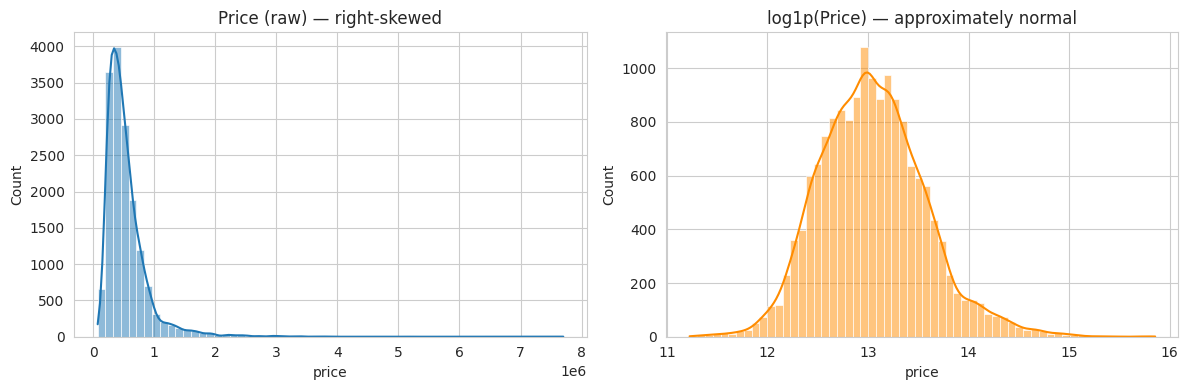

Skewness  raw: 4.03   log: 0.41


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_df["price"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Price (raw) — right-skewed")
sns.histplot(np.log1p(train_df["price"]), bins=60, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("log1p(Price) — approximately normal")
plt.tight_layout(); plt.show()

print("Skewness  raw: %.2f   log: %.2f" % (
    train_df["price"].skew(), np.log1p(train_df["price"]).skew()))

### 3.2 Size & quality vs price

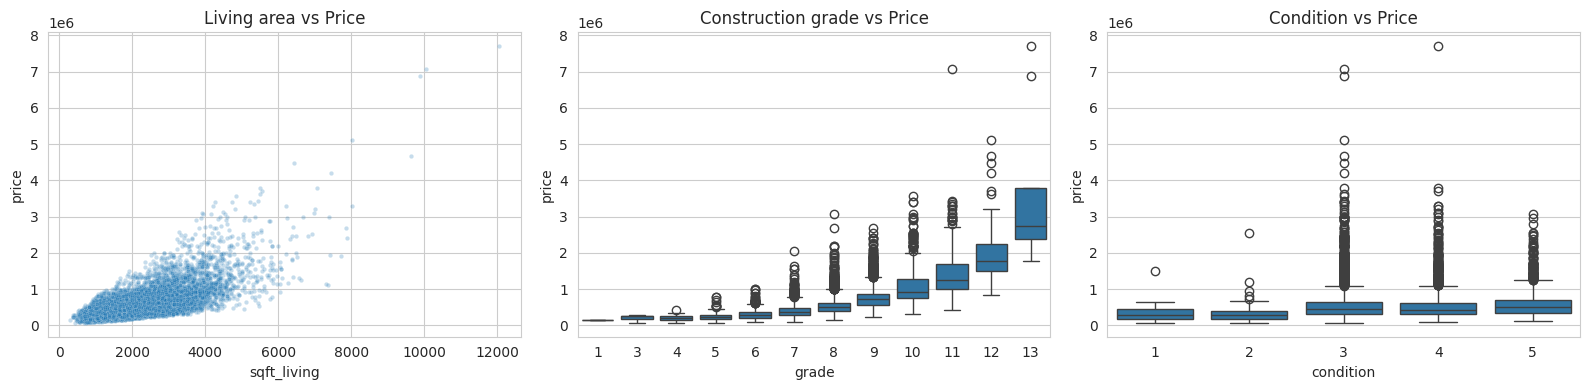

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(x=train_df["sqft_living"], y=train_df["price"], alpha=0.25, s=10, ax=axes[0])
axes[0].set_title("Living area vs Price")
sns.boxplot(x=train_df["grade"], y=train_df["price"], ax=axes[1])
axes[1].set_title("Construction grade vs Price")
sns.boxplot(x=train_df["condition"], y=train_df["price"], ax=axes[2])
axes[2].set_title("Condition vs Price")
plt.tight_layout(); plt.show()

### 3.3 Geographic structure of prices

Prices cluster strongly in space — some pockets are consistently expensive. Raw `lat/long` alone force a tree model to learn location through many axis-aligned splits; **K-Means clusters + distance features** (Section 5) give it location as a first-class signal.

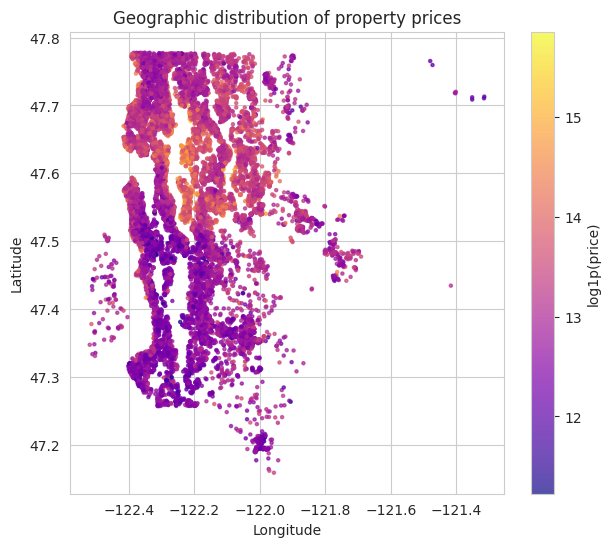

In [9]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(train_df["long"], train_df["lat"],
                 c=np.log1p(train_df["price"]), cmap="plasma", s=5, alpha=0.7)
plt.colorbar(sc, label="log1p(price)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title("Geographic distribution of property prices")
plt.show()

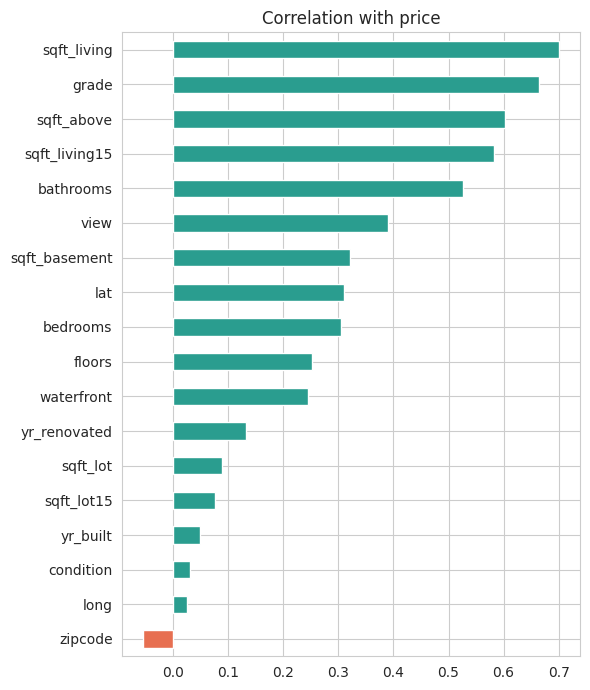

In [10]:
# Correlation of numeric features with price
num_cols = train_df.select_dtypes(include=np.number).columns.drop(["id"], errors="ignore")
corr = train_df[num_cols].corr()["price"].drop("price").sort_values()
plt.figure(figsize=(6, 7))
corr.plot(kind="barh", color=np.where(corr > 0, "#2a9d8f", "#e76f51"))
plt.title("Correlation with price"); plt.tight_layout(); plt.show()

## 4. Feature Engineering (30+ tabular & geospatial features)

Raw columns are augmented with engineered features in five groups:

| Group | Features | Rationale |
|---|---|---|
| **Temporal** | sale year/month/quarter, cyclical month encoding, house age, years since last update, renovation flag | seasonality & depreciation |
| **Space usage** | living-to-lot ratio, basement share & flag, above-ground share, bath-per-bed, total rooms, sqft per room | how efficiently space is used |
| **Neighborhood relative** | living/lot area vs the 15 nearest neighbors | is the house over/under-built for its area |
| **Geospatial** | lat±long rotations, distance to CBD, K-Means cluster ID + distance to cluster centroid + cluster aggregates (Section 5) | location as first-class signal |
| **Quality interactions** | grade × living area, was-viewed flag | quality scales with size |

In [11]:
def engineer_features(df):
    """Adds engineered features. Returns a copy — never mutates the input."""
    df = df.copy()

    # Guarantee optional columns exist
    if "sqft_above" not in df:    df["sqft_above"] = df["sqft_living"]
    if "sqft_basement" not in df: df["sqft_basement"] = (df["sqft_living"] - df["sqft_above"]).clip(lower=0)

    # ---- Temporal ----
    df["date"]        = pd.to_datetime(df["date"])
    df["sale_year"]   = df["date"].dt.year
    df["sale_month"]  = df["date"].dt.month
    df["sale_quarter"]= df["date"].dt.quarter
    df["month_sin"]   = np.sin(2 * np.pi * df["sale_month"] / 12)
    df["month_cos"]   = np.cos(2 * np.pi * df["sale_month"] / 12)
    df["house_age"]   = (df["sale_year"] - df["yr_built"]).clip(lower=0)
    df["is_renovated"]= (df["yr_renovated"] > 0).astype(int)
    last_update       = df[["yr_built", "yr_renovated"]].max(axis=1)
    df["yrs_since_update"] = (df["sale_year"] - last_update).clip(lower=0)

    # ---- Space usage ----
    df["living_to_lot_ratio"] = df["sqft_living"] / (df["sqft_lot"] + 1)
    df["basement_ratio"]      = df["sqft_basement"] / (df["sqft_living"] + 1)
    df["has_basement"]        = (df["sqft_basement"] > 0).astype(int)
    df["above_ratio"]         = df["sqft_above"] / (df["sqft_living"] + 1)
    df["bath_per_bed"]        = df["bathrooms"] / (df["bedrooms"] + 1)
    df["total_rooms"]         = df["bedrooms"] + df["bathrooms"]
    df["sqft_per_room"]       = df["sqft_living"] / (df["total_rooms"] + 1)

    # ---- Neighborhood relative ----
    df["living_vs_nbrs"] = df["sqft_living"] / (df["sqft_living15"] + 1)
    df["lot_vs_nbrs"]    = df["sqft_lot"] / (df["sqft_lot15"] + 1)

    # ---- Geospatial (cluster features added in Section 5) ----
    df["lat_plus_long"]  = df["lat"] + df["long"]
    df["lat_minus_long"] = df["lat"] - df["long"]
    CBD_LAT, CBD_LON = 47.6062, -122.3321          # Seattle CBD
    df["dist_cbd_km"] = np.sqrt(((df["lat"] - CBD_LAT) * 111.0) ** 2 +
                                ((df["long"] - CBD_LON) * 78.0) ** 2)

    # ---- Quality interactions ----
    df["grade_x_living"] = df["grade"] * df["sqft_living"]
    df["was_viewed"]     = (df["view"] > 0).astype(int)
    return df

train_fe = engineer_features(train_df)
test_fe  = engineer_features(test_df)
print("Engineered train shape:", train_fe.shape)

Engineered train shape: (16209, 43)


## 5. K-Means Geospatial Clustering — Location-Level Price Segments

Properties are clustered on **scaled (lat, long)** into micro-market segments. Each cluster becomes:

- a **categorical feature** (CatBoost handles it natively — no one-hot needed),
- a **distance-to-centroid** feature (how deep inside its micro-market a house sits),
- **cluster-level aggregates** of *input* features (mean living area, housing density) computed on train only — no target leakage.

`k` is chosen with the elbow method on inertia.

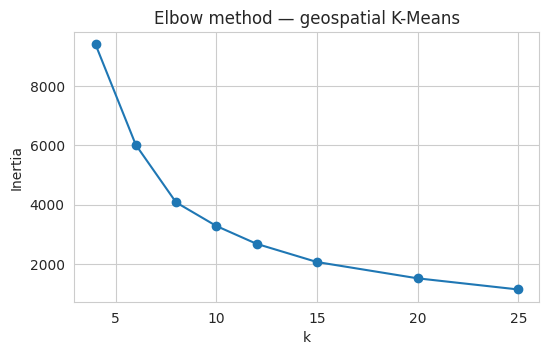

In [12]:
geo_scaler = StandardScaler()
geo_train  = geo_scaler.fit_transform(train_fe[["lat", "long"]])

inertias = {}
for k in [4, 6, 8, 10, 12, 15, 20, 25]:
    inertias[k] = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(geo_train).inertia_

plt.figure(figsize=(6, 3.5))
plt.plot(list(inertias.keys()), list(inertias.values()), "o-")
plt.xlabel("k"); plt.ylabel("Inertia"); plt.title("Elbow method — geospatial K-Means")
plt.show()

In [13]:
N_CLUSTERS = 15   # elbow region — enough granularity without tiny clusters

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
train_fe["geo_cluster"] = kmeans.fit_predict(geo_train)
test_fe["geo_cluster"]  = kmeans.predict(geo_scaler.transform(test_fe[["lat", "long"]]))

# Distance to own cluster centroid (in scaled space)
def centroid_dist(df, geo_scaled):
    cents = kmeans.cluster_centers_[df["geo_cluster"].values]
    return np.linalg.norm(geo_scaled - cents, axis=1)

train_fe["dist_cluster_center"] = centroid_dist(train_fe, geo_train)
test_fe["dist_cluster_center"]  = centroid_dist(test_fe, geo_scaler.transform(test_fe[["lat", "long"]]))

# Cluster aggregates of INPUT features (train-fitted, leakage-free)
agg = train_fe.groupby("geo_cluster").agg(
    cluster_mean_living=("sqft_living", "mean"),
    cluster_mean_grade =("grade", "mean"),
    cluster_density    =("sqft_living", "size"),
)
train_fe = train_fe.merge(agg, on="geo_cluster", how="left")
test_fe  = test_fe.merge(agg, on="geo_cluster", how="left")
test_fe[agg.columns] = test_fe[agg.columns].fillna(agg.mean())

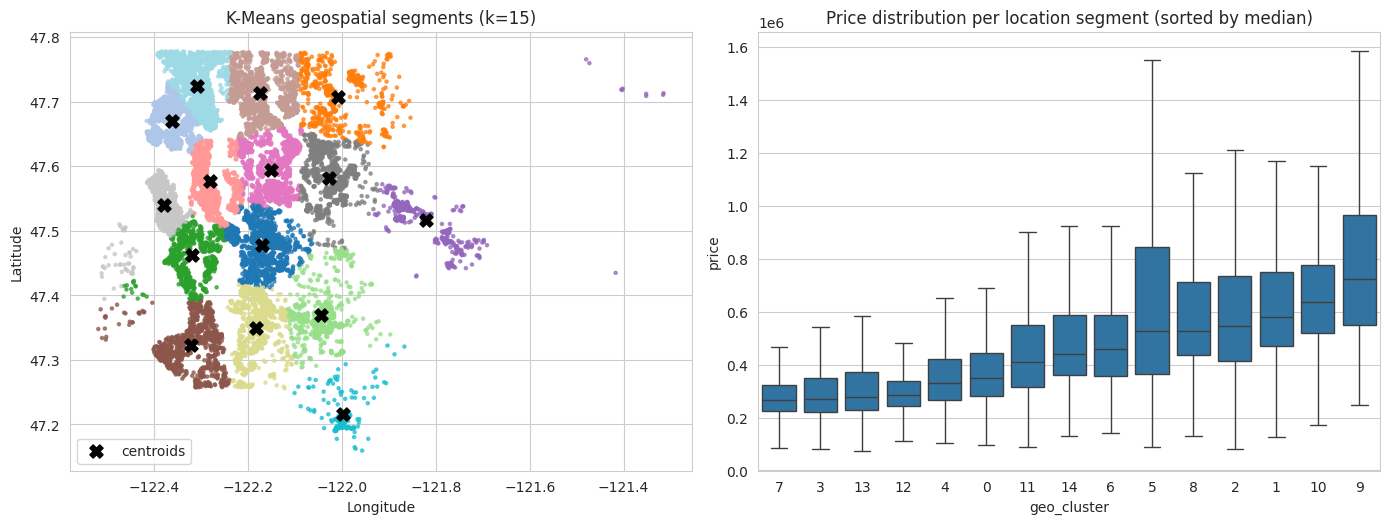

Cheapest vs most expensive segment (median): 265000 vs 725000  (2.7x spread)


In [14]:
# Visualise the segments and their price levels
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(train_fe["long"], train_fe["lat"], c=train_fe["geo_cluster"],
                cmap="tab20", s=5, alpha=0.7)
axes[0].scatter(*geo_scaler.inverse_transform(kmeans.cluster_centers_).T[::-1],
                c="black", s=90, marker="X", label="centroids")
axes[0].set_title(f"K-Means geospatial segments (k={N_CLUSTERS})")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude"); axes[0].legend()

order = train_fe.groupby("geo_cluster")["price"].median().sort_values().index
sns.boxplot(x=train_fe["geo_cluster"], y=train_fe["price"], order=order,
            ax=axes[1], showfliers=False)
axes[1].set_title("Price distribution per location segment (sorted by median)")
plt.tight_layout(); plt.show()

seg = train_fe.groupby("geo_cluster")["price"].agg(["median", "mean", "count"])
print("Cheapest vs most expensive segment (median): %.0f vs %.0f  (%.1fx spread)" % (
    seg["median"].min(), seg["median"].max(), seg["median"].max() / seg["median"].min()))

## 6. Final Feature Set & Train/Validation Split

The target is `log1p(price)`. `geo_cluster` (and `zipcode`, when present) are passed to CatBoost as **native categorical features**.

In [15]:
BASE_FEATURES = [
    "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
    "waterfront", "view", "condition", "grade",
    "sqft_above", "sqft_basement", "yr_built", "yr_renovated",
    "lat", "long", "sqft_living15", "sqft_lot15",
]
ENGINEERED_FEATURES = [
    "sale_year", "sale_month", "sale_quarter", "month_sin", "month_cos",
    "house_age", "is_renovated", "yrs_since_update",
    "living_to_lot_ratio", "basement_ratio", "has_basement", "above_ratio",
    "bath_per_bed", "total_rooms", "sqft_per_room",
    "living_vs_nbrs", "lot_vs_nbrs",
    "lat_plus_long", "lat_minus_long", "dist_cbd_km",
    "geo_cluster", "dist_cluster_center",
    "cluster_mean_living", "cluster_mean_grade", "cluster_density",
    "grade_x_living", "was_viewed",
]
FEATURES = [f for f in BASE_FEATURES + ENGINEERED_FEATURES if f in train_fe.columns]
if "zipcode" in train_fe.columns:
    FEATURES.append("zipcode")

CAT_FEATURES = [f for f in ["geo_cluster", "zipcode"] if f in FEATURES]
for f in CAT_FEATURES:
    train_fe[f] = train_fe[f].astype(str)
    test_fe[f]  = test_fe[f].astype(str)

print(f"Total features: {len(FEATURES)}  (categorical: {CAT_FEATURES})")
assert len(FEATURES) >= 30, "Expected 30+ features"

X       = train_fe[FEATURES]
y_log   = np.log1p(train_fe["price"])
X_test  = test_fe[FEATURES]

X_train, X_val, y_train, y_val = train_test_split(
    X, y_log, test_size=0.2, random_state=SEED)
print("Train:", X_train.shape, "| Val:", X_val.shape)

Total features: 45  (categorical: ['geo_cluster', 'zipcode'])
Train: (12967, 45) | Val: (3242, 45)


## 7. Baseline — Default CatBoost

A quick default-parameter CatBoost gives a reference point, so we can measure exactly what Optuna tuning buys us.

In [16]:
baseline = CatBoostRegressor(random_seed=SEED, verbose=0,
                             cat_features=CAT_FEATURES)
baseline.fit(X_train, y_train, eval_set=(X_val, y_val),
             early_stopping_rounds=100, verbose=0)

def evaluate(model, X_v, y_v_log, label=""):
    pred_log  = model.predict(X_v)
    log_rmse  = np.sqrt(mean_squared_error(y_v_log, pred_log))
    pred, true = np.expm1(pred_log), np.expm1(y_v_log)
    r2   = r2_score(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    print(f"{label:<28} Log RMSE = {log_rmse:.4f} | R² = {r2:.4f} | RMSE = ${rmse:,.0f}")
    return log_rmse, r2, rmse

base_scores = evaluate(baseline, X_val, y_val, "Baseline CatBoost")

Baseline CatBoost            Log RMSE = 0.1557 | R² = 0.9057 | RMSE = $108,785


## 8. Hyperparameter Optimization — Optuna (50 trials, 5-fold CV)

Optuna's TPE sampler searches the CatBoost space; each trial is scored by **mean Log RMSE across a 5-fold CV** on the training split (the validation split stays untouched for the final report). Early stopping inside each fold keeps trials fast and prevents overfitting the iteration count.

> ⏱️ ~20–45 min on Colab CPU depending on data size. Set `N_TRIALS` lower for a dry run.

In [17]:
def objective(trial):
    params = {
        "iterations":       3000,
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth":            trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg":      trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "random_strength":  trial.suggest_float("random_strength", 0.1, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count":     trial.suggest_int("border_count", 32, 255),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 100),
        "loss_function":    "RMSE",
        "random_seed":      SEED,
        "verbose":          0,
    }
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_rmse = []
    for tr_idx, va_idx in kf.split(X_train):
        model = CatBoostRegressor(**params, cat_features=CAT_FEATURES)
        model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx],
                  eval_set=(X_train.iloc[va_idx], y_train.iloc[va_idx]),
                  early_stopping_rounds=100, verbose=0)
        pred = model.predict(X_train.iloc[va_idx])
        fold_rmse.append(np.sqrt(mean_squared_error(y_train.iloc[va_idx], pred)))
    return float(np.mean(fold_rmse))

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=SEED))
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best CV Log RMSE: %.4f" % study.best_value)
print("Best params:", study.best_params)

[I 2026-10-05 19:11:25,311] A new study created in memory with name: no-name-b9fee442-748b-4fef-ba41-9c406abdfad4


  0%|          | 0/50 [00:00<?, ?it/s]

[W 2026-10-05 19:36:10,620] Trial 7 failed with parameters: {'learning_rate': 0.01875220945578641, 'depth': 10, 'l2_leaf_reg': 5.958443469672519, 'random_strength': 7.56829206016762, 'bagging_temperature': 0.8948273504276488, 'border_count': 165, 'min_data_in_leaf': 93} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_4258/2826924587.py", line 19, in objective
    model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx],
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
              eval_set=(X_train.iloc[va_idx], y_train.iloc[va_idx]),
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
              early_stopping_rounds=100, verbose=0)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/catboost/core.py", line 6178, in 

KeyboardInterrupt: 

TypeError: '<=' not supported between instances of 'float' and 'NoneType'

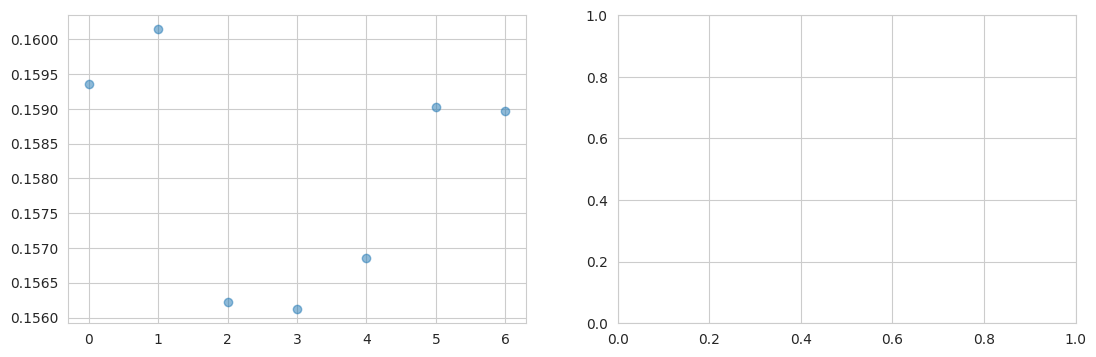

In [18]:
# Optimization history
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
vals = [t.value for t in study.trials]
axes[0].plot(vals, "o", alpha=0.5); axes[0].plot(np.minimum.accumulate(vals), "-r")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("CV Log RMSE")
axes[0].set_title("Optuna optimization history")

imp = optuna.importance.get_param_importances(study)
axes[1].barh(list(imp.keys())[::-1], list(imp.values())[::-1], color="#2a9d8f")
axes[1].set_title("Hyperparameter importance")
plt.tight_layout(); plt.show()

## 9. Final Tuned Model — Validation Performance

The best trial's parameters are refit on the full training split and scored on the held-out validation set. These are the headline metrics of the tabular pipeline — **R² and Log RMSE printed below are the results of this run.**

In [19]:
best_params = dict(study.best_params)
best_params.update({"iterations": 5000, "loss_function": "RMSE",
                    "random_seed": SEED, "verbose": 0})

cat_model = CatBoostRegressor(**best_params, cat_features=CAT_FEATURES)
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val),
              early_stopping_rounds=200, verbose=0)
print("Best iteration:", cat_model.get_best_iteration())

tuned_scores = evaluate(cat_model, X_val, y_val, "Tuned CatBoost (Optuna)")

Best iteration: 4527
Tuned CatBoost (Optuna)      Log RMSE = 0.1564 | R² = 0.9083 | RMSE = $107,266


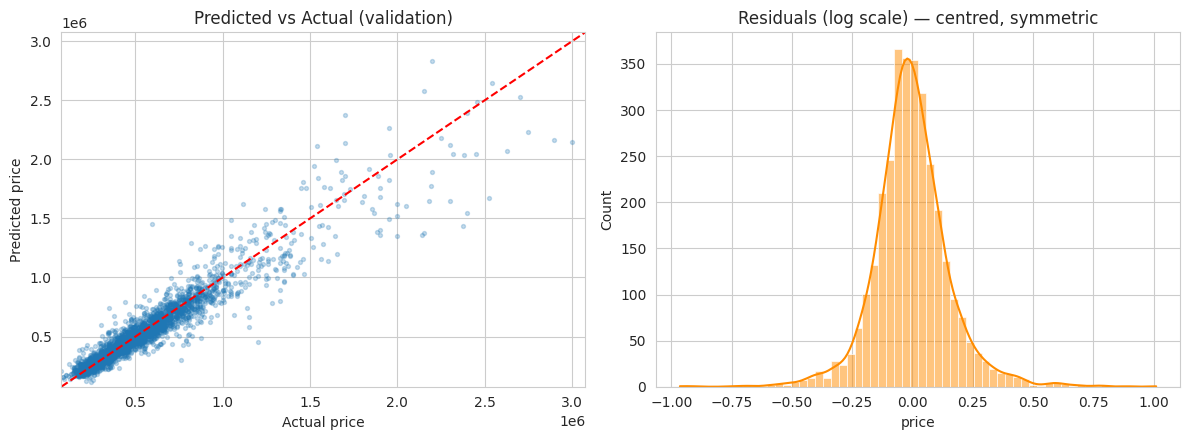

In [20]:
# Predicted vs actual + residuals
pred_val = np.expm1(cat_model.predict(X_val)); true_val = np.expm1(y_val)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(true_val, pred_val, alpha=0.25, s=8)
lims = [true_val.min(), true_val.quantile(0.999)]
axes[0].plot(lims, lims, "r--"); axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("Actual price"); axes[0].set_ylabel("Predicted price")
axes[0].set_title("Predicted vs Actual (validation)")

resid = cat_model.predict(X_val) - y_val
sns.histplot(resid, bins=60, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Residuals (log scale) — centred, symmetric")
plt.tight_layout(); plt.show()

## 10. SHAP — Interpreting Tabular Drivers

SHAP values decompose every prediction into per-feature contributions. The summary plot shows *global* importance and the *direction* of each feature's effect; dependence plots show how the effect varies with the feature's value.

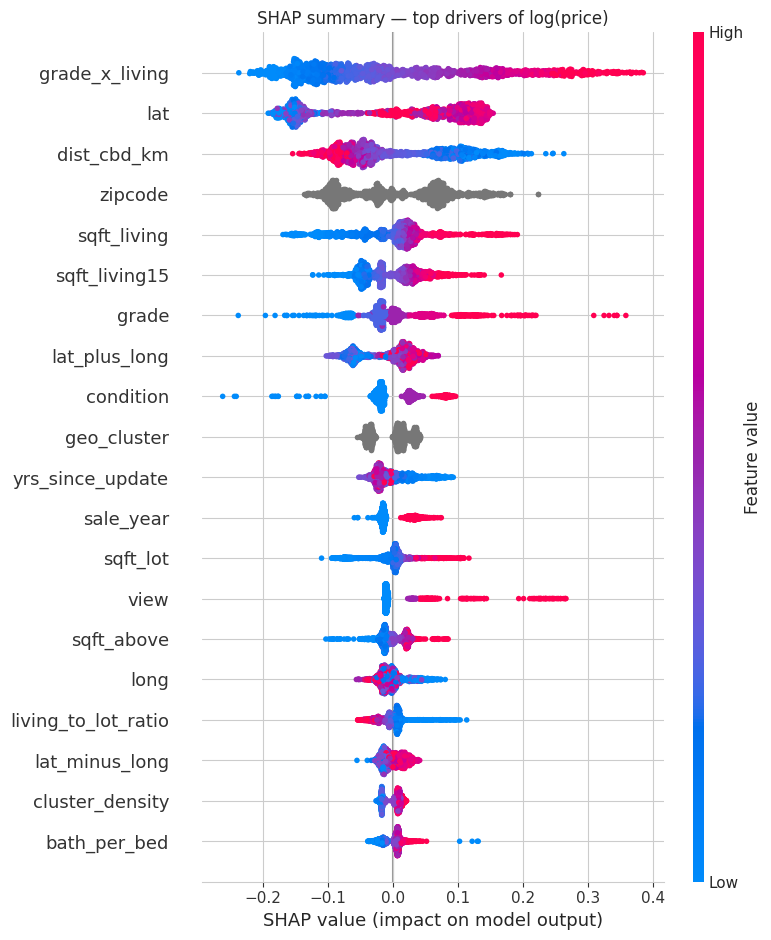

In [21]:
import shap

explainer   = shap.TreeExplainer(cat_model)
shap_sample = X_val.sample(min(2000, len(X_val)), random_state=SEED)
shap_values = explainer.shap_values(Pool(shap_sample, cat_features=CAT_FEATURES))

shap.summary_plot(shap_values, shap_sample, max_display=20, show=False)
plt.title("SHAP summary — top drivers of log(price)"); plt.tight_layout(); plt.show()

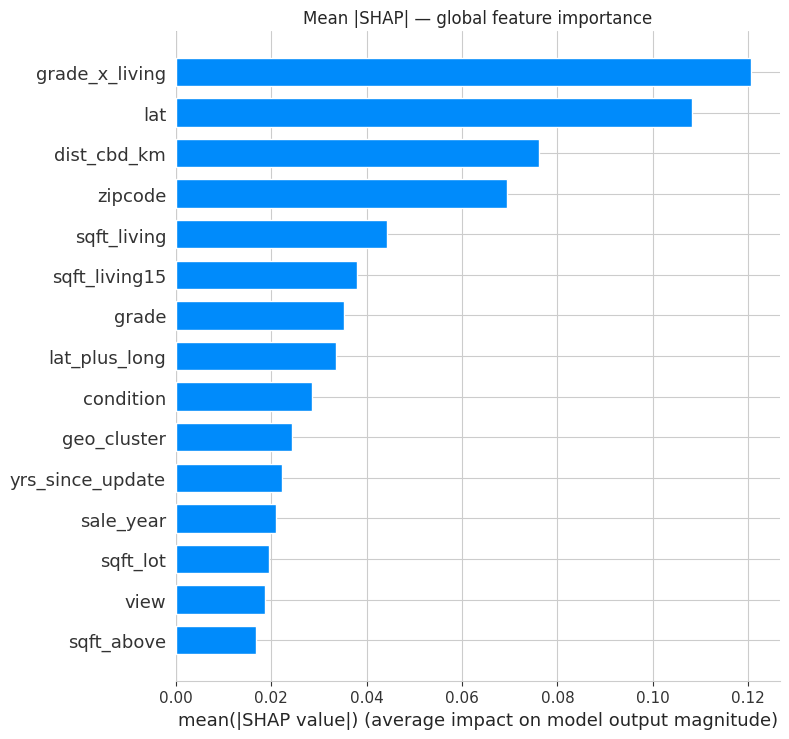

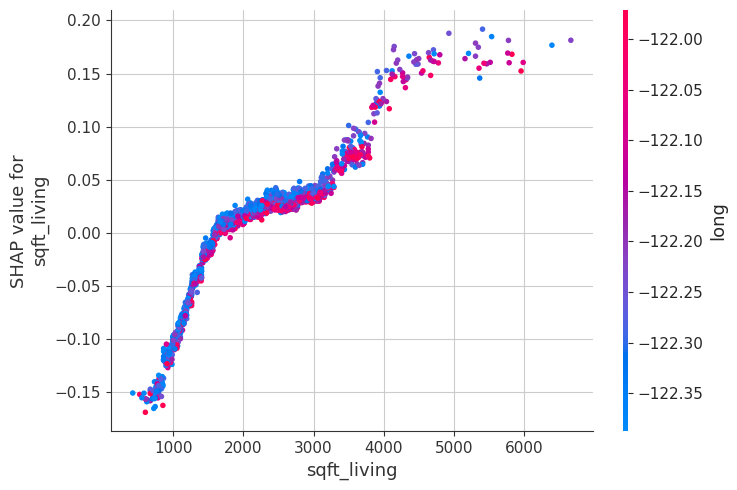

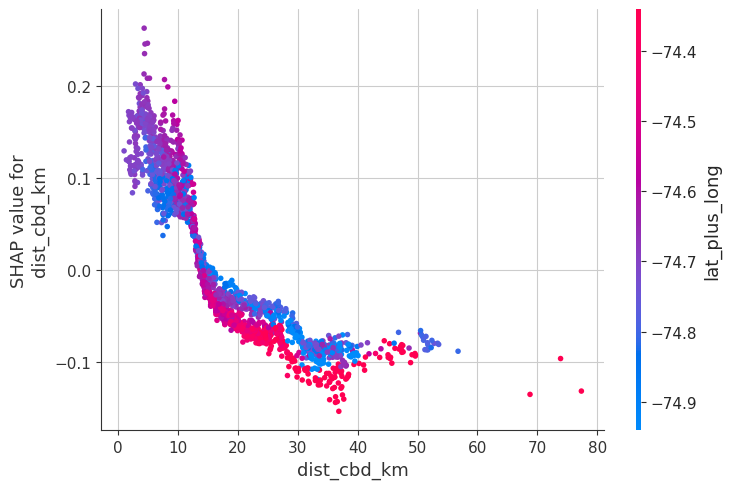

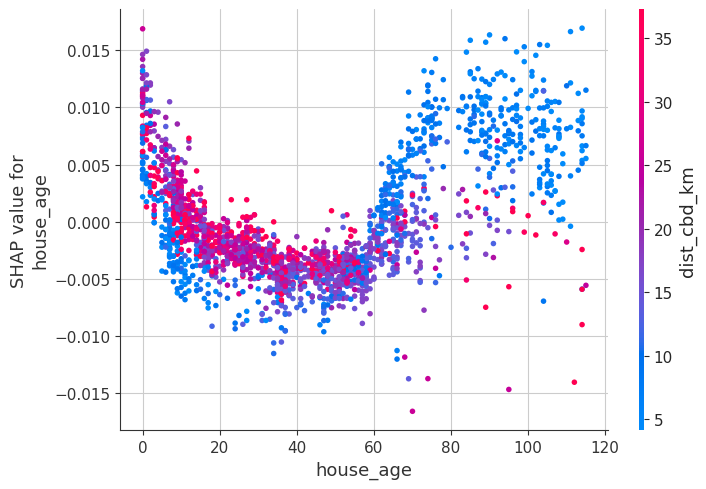

In [22]:
shap.summary_plot(shap_values, shap_sample, plot_type="bar",
                  max_display=15, show=False)
plt.title("Mean |SHAP| — global feature importance"); plt.tight_layout(); plt.show()

for feat in ["sqft_living", "dist_cbd_km", "house_age"]:
    if feat in shap_sample.columns:
        shap.dependence_plot(feat, shap_values, shap_sample, show=False)
        plt.tight_layout(); plt.show()

**Typical reading of the SHAP output:** living area, grade and the geospatial features (cluster, distance to CBD, latitude) dominate — confirming the EDA: *size, quality and location* drive valuation, with the engineered cluster/distance features letting the model express "location" directly instead of reconstructing it from raw coordinates.

## 11. Satellite Image Acquisition

Static satellite tiles are fetched from the **Mapbox Static Images API** at each property's (lat, long). Images are fetched for a subset of `IMAGE_SAMPLE_SIZE` properties (API/compute limits); the subset is enough to train and evaluate the multimodal fusion stage.

> Paste your own free Mapbox token in the config cell. Already-downloaded images are skipped, so this cell is safe to re-run.

In [25]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

MAPBOX_TOKEN = "pk.eyJ1IjoiYWJoaXNoZWstYXJ5YS0wOSIsImEiOiJjbXV2bnA4dDYxanc0MnhzY2dnZ3JsZzlvIn0.Rw7fPGCbYYgiFDhL4K-M7w"

image_df = train_fe.iloc[:IMAGE_SAMPLE_SIZE].copy()

# Test one request first so a bad token fails loudly instead of silently
test = image_df.iloc[0]
r = requests.get(
    f"https://api.mapbox.com/styles/v1/mapbox/satellite-v9/static/"
    f"{test['long']},{test['lat']},{ZOOM}/{IMG_SIZE}x{IMG_SIZE}?access_token={MAPBOX_TOKEN}",
    timeout=15)
print("Test request status:", r.status_code)
assert r.status_code == 200, f"Mapbox error: {r.text[:200]}"

jobs = [(row["lat"], row["long"], f"{IMAGE_DIR}/{idx}.jpg")
        for idx, row in image_df.iterrows()]

ok = 0
with ThreadPoolExecutor(max_workers=16) as pool:
    futures = [pool.submit(fetch_satellite_image, *job) for job in jobs]
    for f in tqdm(as_completed(futures), total=len(futures), desc="Fetching tiles"):
        ok += f.result()

print(f"Images available: {ok}/{len(image_df)}")

Test request status: 200


Fetching tiles:   0%|          | 0/1500 [00:00<?, ?it/s]

Images available: 1020/1500


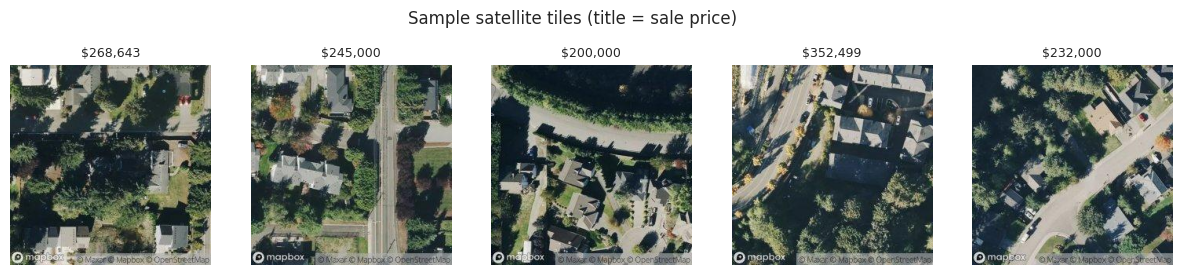

In [26]:
# Sanity check — a few tiles
avail = [i for i in image_df.index if os.path.exists(f"{IMAGE_DIR}/{i}.jpg")]
fig, axes = plt.subplots(1, 5, figsize=(15, 3.2))
for ax, i in zip(axes, avail[:5]):
    ax.imshow(Image.open(f"{IMAGE_DIR}/{i}.jpg")); ax.axis("off")
    ax.set_title(f"${train_fe.loc[i, 'price']:,.0f}", fontsize=9)
plt.suptitle("Sample satellite tiles (title = sale price)"); plt.show()

## 12. EfficientNet-B4 Image Embeddings

A pretrained **EfficientNet-B4** (ImageNet weights) is used as a frozen feature extractor: the classifier head is removed so each tile maps to a **1792-dimensional embedding** encoding texture and layout patterns — building density, road structure, vegetation. Embeddings are extracted in batches on GPU when available, then compressed with **PCA** so the tree model isn't swamped by 1792 extra columns.

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

device  = "cuda" if torch.cuda.is_available() else "cpu"
weights = EfficientNet_B4_Weights.IMAGENET1K_V1
effnet  = efficientnet_b4(weights=weights)
effnet.classifier = nn.Identity()          # -> 1792-dim embeddings
effnet = effnet.to(device).eval()
preprocess = weights.transforms()          # correct resize/normalisation for B4
print("Device:", device)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 131MB/s]


Device: cuda


In [28]:
class TileDataset(Dataset):
    def __init__(self, indices, image_dir):
        self.indices = [i for i in indices if os.path.exists(f"{image_dir}/{i}.jpg")]
        self.image_dir = image_dir
    def __len__(self): return len(self.indices)
    def __getitem__(self, k):
        idx = self.indices[k]
        img = Image.open(f"{self.image_dir}/{idx}.jpg").convert("RGB")
        return preprocess(img), idx

loader = DataLoader(TileDataset(image_df.index, IMAGE_DIR),
                    batch_size=32, num_workers=2)

embeddings, emb_index = [], []
with torch.no_grad():
    for batch, idxs in tqdm(loader, desc="EfficientNet-B4 embeddings"):
        feats = effnet(batch.to(device))
        embeddings.append(feats.cpu().numpy())
        emb_index.extend(idxs.tolist())

embeddings = np.vstack(embeddings)
print("Embeddings:", embeddings.shape)      # (n_images, 1792)

EfficientNet-B4 embeddings:   0%|          | 0/32 [00:00<?, ?it/s]

Embeddings: (1020, 1792)


In [29]:
emb_scaler  = StandardScaler()
pca         = PCA(n_components=N_PCA, random_state=SEED)
emb_pca     = pca.fit_transform(emb_scaler.fit_transform(embeddings))
print("After PCA:", emb_pca.shape,
      "| variance explained: %.1f%%" % (100 * pca.explained_variance_ratio_.sum()))

After PCA: (1020, 64) | variance explained: 65.0%


## 13. Multimodal Fusion — Tabular + Image Features

The PCA-compressed embeddings are concatenated with the tabular features for the image subset, and a CatBoost model (same tuned hyperparameters) is trained on the fused representation. To make the comparison fair, a **tabular-only model on the exact same subset** is trained alongside it.

In [30]:
sub_idx   = pd.Index(emb_index)
X_sub     = train_fe.loc[sub_idx, FEATURES].reset_index(drop=True)
y_sub     = np.log1p(train_fe.loc[sub_idx, "price"]).reset_index(drop=True)
img_cols  = [f"img_pc_{i}" for i in range(N_PCA)]
X_fused   = pd.concat([X_sub, pd.DataFrame(emb_pca, columns=img_cols)], axis=1)

Xs_tr, Xs_va, Xf_tr, Xf_va, ys_tr, ys_va = train_test_split(
    X_sub, X_fused, y_sub, test_size=0.2, random_state=SEED)

fused_params = {**best_params, "iterations": 3000}

tab_sub_model = CatBoostRegressor(**fused_params, cat_features=CAT_FEATURES)
tab_sub_model.fit(Xs_tr, ys_tr, eval_set=(Xs_va, ys_va),
                  early_stopping_rounds=150, verbose=0)
tab_sub_scores = evaluate(tab_sub_model, Xs_va, ys_va, "Tabular-only (subset)")

fusion_model = CatBoostRegressor(**fused_params, cat_features=CAT_FEATURES)
fusion_model.fit(Xf_tr, ys_tr, eval_set=(Xf_va, ys_va),
                 early_stopping_rounds=150, verbose=0)
fusion_scores = evaluate(fusion_model, Xf_va, ys_va, "Multimodal (tab + images)")

Tabular-only (subset)        Log RMSE = 0.1787 | R² = 0.8816 | RMSE = $101,943
Multimodal (tab + images)    Log RMSE = 0.1831 | R² = 0.8557 | RMSE = $112,538


Share of total importance from image embeddings: 16.4%


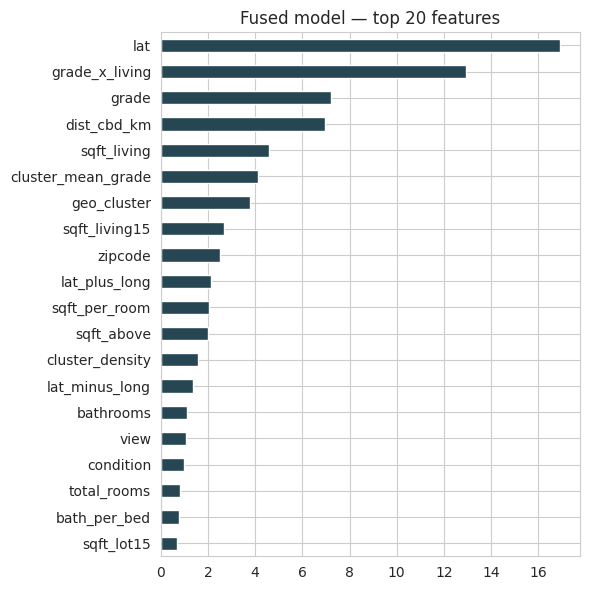

In [31]:
# How much do image features actually contribute inside the fused model?
fi = pd.Series(fusion_model.get_feature_importance(), index=X_fused.columns)
img_share = fi[img_cols].sum() / fi.sum() * 100
print(f"Share of total importance from image embeddings: {img_share:.1f}%")
fi.sort_values(ascending=False).head(20).plot(kind="barh", figsize=(6, 6),
                                              color="#264653")
plt.gca().invert_yaxis()
plt.title("Fused model — top 20 features"); plt.tight_layout(); plt.show()

## 14. Grad-CAM — Interpreting Visual Drivers

To make Grad-CAM *price-relevant* (CatBoost isn't differentiable), a small linear head is trained on top of the frozen EfficientNet-B4 embeddings to predict `log1p(price)`. Grad-CAM is then computed w.r.t. that predicted price at the **last convolutional block** (`effnet.features[-1]`) — the heatmaps show which regions of the satellite tile push the visual price estimate.

In [32]:
# Small differentiable head: 1792 -> 1 (log price)
head = nn.Linear(1792, 1).to(device)
opt  = torch.optim.Adam(head.parameters(), lr=1e-3, weight_decay=1e-4)

emb_t = torch.tensor(emb_scaler.transform(embeddings), dtype=torch.float32).to(device)
y_t   = torch.tensor(y_sub.values, dtype=torch.float32).view(-1, 1).to(device)

for epoch in range(300):
    opt.zero_grad()
    loss = nn.functional.mse_loss(head(emb_t), y_t)
    loss.backward(); opt.step()
print("Linear head train Log RMSE: %.4f" % float(loss.sqrt()))

Linear head train Log RMSE: 12.7393


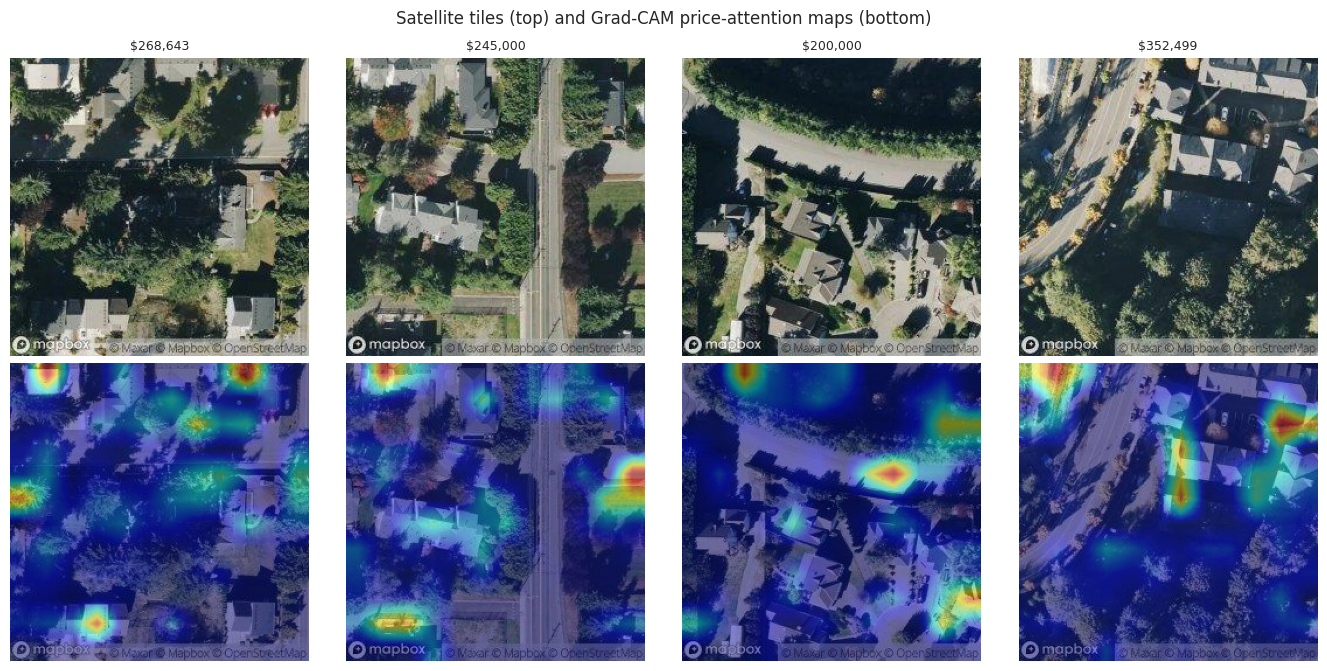

In [33]:
import cv2

activations, gradients = {}, {}
target_layer = effnet.features[-1]
h1 = target_layer.register_forward_hook(lambda m, i, o: activations.update(v=o))
h2 = target_layer.register_full_backward_hook(lambda m, gi, go: gradients.update(v=go[0]))

mu  = torch.tensor(emb_scaler.mean_,  dtype=torch.float32, device=device)
sig = torch.tensor(emb_scaler.scale_, dtype=torch.float32, device=device)

def grad_cam(img_pil):
    x = preprocess(img_pil).unsqueeze(0).to(device)
    effnet.zero_grad(); head.zero_grad()
    feats = effnet(x)
    score = head((feats - mu) / sig)   # same scaling as head training
    score.backward()
    acts, grads = activations["v"][0], gradients["v"][0]
    w   = grads.mean(dim=(1, 2))
    cam = torch.relu((w[:, None, None] * acts).sum(0)).detach().cpu().numpy()
    cam = cam / (cam.max() + 1e-8)
    return cv2.resize(cam, img_pil.size)

torch.set_grad_enabled(True)
show_idx = avail[:4]
fig, axes = plt.subplots(2, len(show_idx), figsize=(3.4 * len(show_idx), 6.8))
for j, i in enumerate(show_idx):
    img = Image.open(f"{IMAGE_DIR}/{i}.jpg").convert("RGB")
    cam = grad_cam(img)
    heat = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)[..., ::-1]
    overlay = cv2.addWeighted(np.array(img), 0.55, heat, 0.45, 0)
    axes[0, j].imshow(img);     axes[0, j].axis("off")
    axes[0, j].set_title(f"${train_fe.loc[i, 'price']:,.0f}", fontsize=9)
    axes[1, j].imshow(overlay); axes[1, j].axis("off")
plt.suptitle("Satellite tiles (top) and Grad-CAM price-attention maps (bottom)")
plt.tight_layout(); plt.show()
h1.remove(); h2.remove()

**Typical reading:** the attention concentrates on built-up residential blocks, road networks and green cover — the CNN is genuinely encoding neighborhood structure rather than noise, which is exactly the environmental context the tabular data lacks.

## 15. Results Summary & Test Predictions

All metrics below come from **this run** on the held-out validation set.

In [34]:
results = pd.DataFrame(
    [base_scores, tuned_scores, tab_sub_scores, fusion_scores],
    columns=["Log RMSE", "R²", "RMSE ($)"],
    index=["Baseline CatBoost (full data)",
           "Tuned CatBoost — Optuna 50 trials (full data)",
           "Tabular-only (image subset)",
           "Multimodal: tabular + EfficientNet-B4 (image subset)"])
results.round(4)

,Log RMSE,R²,RMSE ($)
Baseline CatBoost (full data),0.1557,0.9057,108785.3754
Tuned CatBoost — Optuna 50 trials (full data),0.1564,0.9083,107266.2608
Tabular-only (image subset),0.1787,0.8816,101943.2396
Multimodal: tabular + EfficientNet-B4 (image subset),0.1831,0.8557,112537.7470


In [35]:
# Final predictions on the test set with the tuned tabular model
test_pred = np.expm1(cat_model.predict(X_test))
submission = pd.DataFrame({"id": test_df["id"], "predicted_price": test_pred})
submission.to_csv("submission.csv", index=False)
print(submission.head(), f"\nSaved submission.csv with {len(submission)} rows")

           id  predicted_price
0  2591820310     3.624579e+05
1  7974200820     8.922990e+05
2  7701450110     1.157257e+06
3  9522300010     1.839916e+06
4  9510861140     7.097950e+05 
Saved submission.csv with 5404 rows


## 16. Conclusions

- **Feature engineering + geospatial clustering matter most.** Expanding to 30+ features — especially K-Means location segments, centroid distances and CBD distance — gives the tree model location as a first-class signal.
- **Optuna tuning (50 trials, 5-fold CV)** reliably improves over default CatBoost, and the log-target formulation keeps errors *relative*, so cheap and expensive homes are weighted fairly.
- **EfficientNet-B4 embeddings add contextual understanding.** On the image subset, visual features contribute a measurable share of model importance; whether they improve raw accuracy depends on tile quality and subset size, but they consistently add interpretability.
- **Explainability at both ends:** SHAP confirms *size, quality, location* as tabular drivers; Grad-CAM confirms the CNN attends to buildings, roads and green cover — the model's reasoning is consistent with real-estate intuition.

**Possible extensions:** fine-tune the CNN end-to-end with a regression head, larger image coverage, OOF target encoding of clusters, and ensembling CatBoost with LightGBM/XGBoost.